#  Sprint 3 — EDA: Importadores
**Insumo:** `mvnd_limpio.csv`

### Objetivos
- Medir concentración de autorizaciones por importador
- Identificar actores dominantes (Pareto)
- Relacionar importador ↔ medicamento


##  Configuración


In [1]:
%pip install pandas matplotlib seaborn scipy openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sys

RUTA_LIMPIO = '../datasets/mvnd_limpio.csv'

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10
sns.set_theme(style='whitegrid', palette='muted')

CARPETA_GRAFICOS = '../graficos/Graficos_eda'
import os
os.makedirs(CARPETA_GRAFICOS, exist_ok=True)

def guardar(fig, nombre):
    ruta = os.path.join(CARPETA_GRAFICOS, nombre)
    fig.savefig(ruta, dpi=150, bbox_inches='tight')
    print(f' Guardado: {ruta}')



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
df = pd.read_csv(RUTA_LIMPIO, encoding='utf-8-sig')
df['FECHA_AUTORIZACION'] = pd.to_datetime(df['FECHA_AUTORIZACION'])

# Corregir nombre de columna año parcial (encoding en CSV)
for c in list(df.columns):
    if 'PARCIAL' in c.upper():
        df = df.rename(columns={c: 'ANIO_PARCIAL'})

print(f' Dataset cargado: {len(df):,} registros × {df.shape[1]} columnas')
print(f'   Período: {df["FECHA_AUTORIZACION"].min().date()} → {df["FECHA_AUTORIZACION"].max().date()}')


 Dataset cargado: 9,413 registros × 21 columnas
   Período: 2018-01-09 → 2026-06-12


## 1. Top importadores


 Guardado: ../graficos/Graficos_eda\05_top20_importadores.png


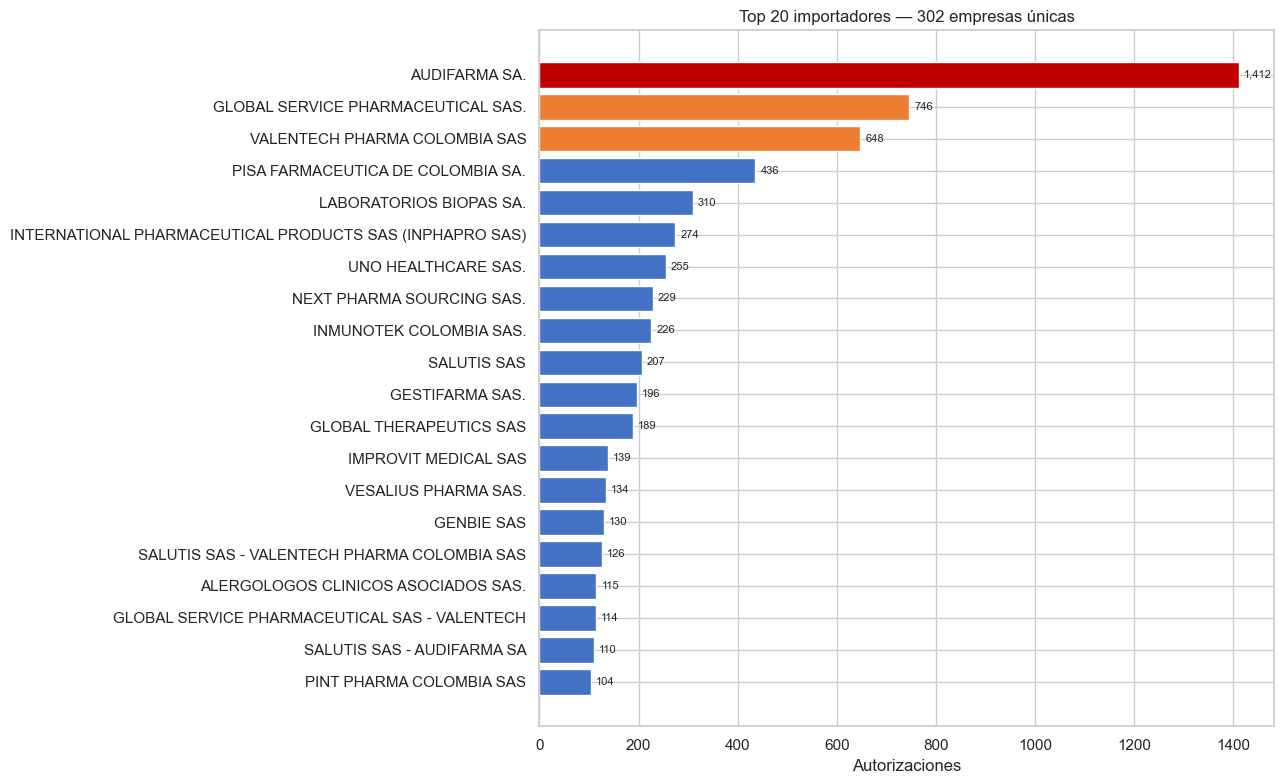

Top 5 concentran: 37.7% | Top 10: 50.4%


In [3]:

n_imp = df['IMPORTADOR'].nunique()
top_imp = df['IMPORTADOR'].value_counts().head(20)
top5_pct = top_imp.head(5).sum() / len(df) * 100
top10_pct = top_imp.head(10).sum() / len(df) * 100

fig, ax = plt.subplots(figsize=(13, 8))
colores = ['#c00000' if i == 0 else '#ED7D31' if i < 3 else '#4472C4' for i in range(len(top_imp))]
ax.barh(top_imp.index[::-1], top_imp.values[::-1], color=colores[::-1])
for bar, val in zip(ax.patches, top_imp.values[::-1]):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=8)
ax.set_title(f'Top 20 importadores — {n_imp} empresas únicas')
ax.set_xlabel('Autorizaciones')
plt.tight_layout()
guardar(plt.gcf(), '05_top20_importadores.png')
plt.show()
print(f'Top 5 concentran: {top5_pct:.1f}% | Top 10: {top10_pct:.1f}%')



## 2. Curva de concentración (Lorenz / Pareto)


 Guardado: ../graficos/Graficos_eda\05_concentracion_importadores.png


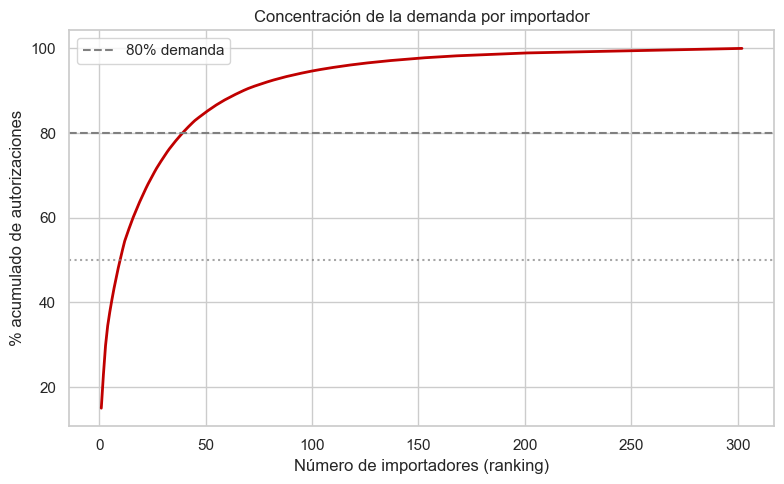

39 importadores acumulan el 80% de las autorizaciones (de 302 totales)


In [4]:

vc = df['IMPORTADOR'].value_counts().sort_values(ascending=False)
cum = vc.cumsum() / vc.sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cum)+1), cum.values, color='#c00000', linewidth=2)
ax.axhline(80, color='gray', linestyle='--', label='80% demanda')
ax.axhline(50, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('Número de importadores (ranking)')
ax.set_ylabel('% acumulado de autorizaciones')
ax.set_title('Concentración de la demanda por importador')
ax.legend()
plt.tight_layout()
guardar(plt.gcf(), '05_concentracion_importadores.png')
plt.show()
n80 = (cum <= 80).sum()
print(f'{n80} importadores acumulan el 80% de las autorizaciones (de {len(vc)} totales)')



## 3. Tipo de solicitud por top 10 importadores


 Guardado: ../graficos/Graficos_eda\05_heatmap_importador_tipo.png


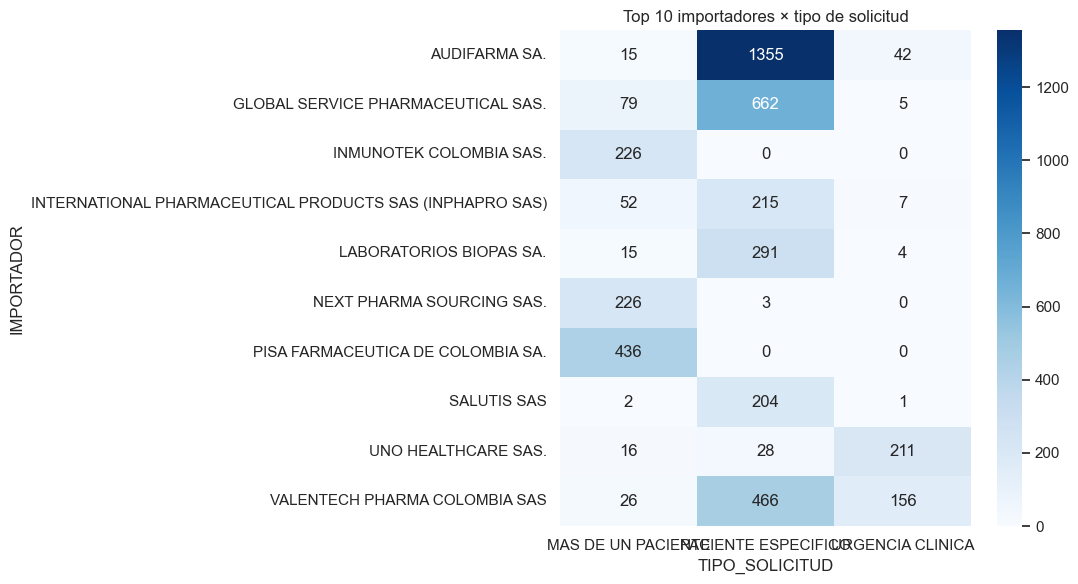

In [5]:

top10 = df['IMPORTADOR'].value_counts().head(10).index
tab = pd.crosstab(df[df['IMPORTADOR'].isin(top10)]['IMPORTADOR'],
                  df[df['IMPORTADOR'].isin(top10)]['TIPO_SOLICITUD'])
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(tab, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Top 10 importadores × tipo de solicitud')
plt.tight_layout()
guardar(plt.gcf(), '05_heatmap_importador_tipo.png')
plt.show()



## 4. Importador × principio activo (top 8 × top 8)


 Guardado: ../graficos/Graficos_eda\05_heatmap_importador_medicamento.png


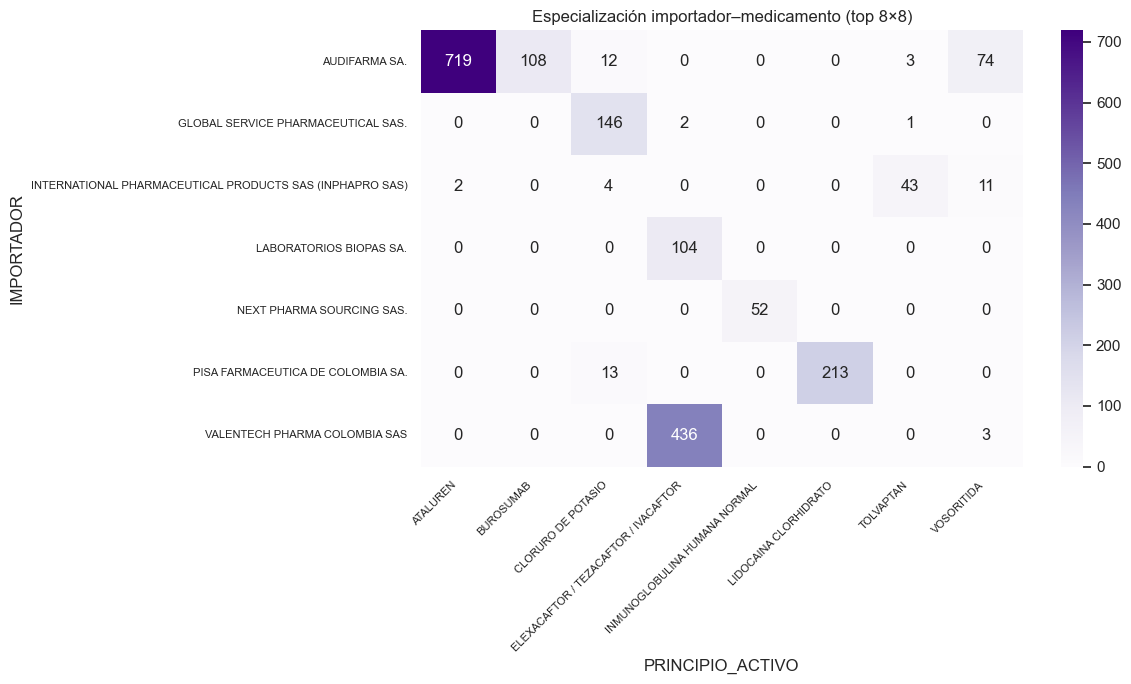

In [6]:

ti = df['IMPORTADOR'].value_counts().head(8).index
tp = df['PRINCIPIO_ACTIVO'].value_counts().head(8).index
sub = df[df['IMPORTADOR'].isin(ti) & df['PRINCIPIO_ACTIVO'].isin(tp)]
tab2 = pd.crosstab(sub['IMPORTADOR'], sub['PRINCIPIO_ACTIVO'])
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(tab2, annot=True, fmt='d', cmap='Purples', ax=ax)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
ax.set_title('Especialización importador–medicamento (top 8×8)')
plt.tight_layout()
guardar(plt.gcf(), '05_heatmap_importador_medicamento.png')
plt.show()



##  Hallazgos — Sprint 3 (Importadores)

| Hallazgo | Evidencia |
|----------|-----------|
| Oligopolio | Pocos importadores concentran la mayoría de autorizaciones |
| Especialización | Algunos importadores dominan medicamentos huérfanos específicos |
| Riesgo sistémico | Dependencia de pocos actores para enfermedades raras |
| Tipo solicitud | Grandes importadores atienden mix de paciente específico y colectivo |

**Siguiente:** `06_EDA_Temporal.ipynb`
